In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv("C:\\Users\\pushp\\OneDrive\\Desktop\\AI &ML project\\student-score-prediction-1\\data\\student_performance_processed.csv")

target = "Exam_Score"

X = df.drop(columns=[target])
Y = df[target]

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [6]:
rf = RandomForestRegressor(random_state=42)

In [7]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [8]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [9]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [10]:
best_model = grid_search.best_estimator_

In [11]:
Y_pred = best_model.predict(X_test)

In [12]:
mae = mean_absolute_error(Y_test, Y_pred)

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

r2 = r2_score(Y_test, Y_pred)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R² Score:", round(r2,4))

MAE : 0.886
RMSE: 1.357
R² Score: 0.8698


In [13]:
comparison = pd.DataFrame({
    "Metric":["MAE","RMSE","R2 Score"],
    "Before Tuning":[
        2.35,     # Replace with your Day 12 values
        3.12,
        0.84
    ],
    "After Tuning":[
        round(mae,3),
        round(rmse,3),
        round(r2,4)
    ]
})

comparison

,Metric,Before Tuning,After Tuning
0,MAE,2.35,0.8860
1,RMSE,3.12,1.3570
2,R2 Score,0.84,0.8698


In [14]:
joblib.dump(best_model,"C:\\Users\\pushp\\OneDrive\\Desktop\\AI &ML project\\student-score-prediction-1\\models\\best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [15]:
comparison.to_csv(
    "C:\\Users\\pushp\\OneDrive\\Desktop\\AI &ML project\\student-score-prediction-1\\data\\final_model_metrics.csv",
    index=False
)

print("Metrics saved successfully!")

Metrics saved successfully!


In [16]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
19,Study_Efficiency,0.397042
20,Academic_Consistency,0.216498
1,Attendance,0.159357
6,Previous_Scores,0.101950
9,Tutoring_Sessions,0.019652
3,Access_to_Resources,0.015875
2,Parental_Involvement,0.015830
0,Hours_Studied,0.010116
13,Peer_Influence,0.007290
17,Distance_from_Home,0.006449


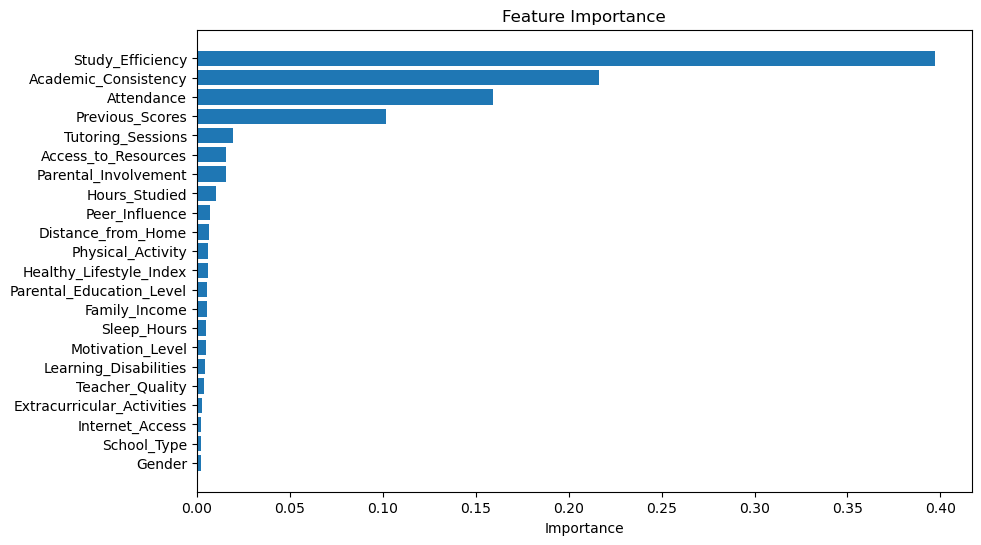

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()